# Exercise: Classify Fashion Items with Support Vector Machines

In this exercise, we'll classify fashion items with support vector machines in scikit-learn. You'll see that image classification is very similar to classification of other data formats, you can directly apply your scikit-learn knowledge from previous lessons! Your tasks are the following:

- Train a support vector machine to classify images of fashion items
- Make predictions and evaluate the model
- Plot the results including a confusion matrix
- Optimize your model using grid search and cross validation
- Evaluate the best model

Acknowledgements: This exercise is loosely based on https://scikit-learn.org/stable/auto_examples/applications/plot_face_recognition.html#sphx-glr-auto-examples-applications-plot-face-recognition-py and https://github.com/zalandoresearch/fashion-mnist

In [14]:
# imports
import sklearn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Data Acquisition and Preprocessing

In [15]:
# load the MNIST dataset
def load_mnist(path, kind='train'):
    import os
    import gzip
    import numpy as np

    """Load MNIST data from `path`"""
    labels_path = os.path.join(path,
                               '%s-labels-idx1-ubyte.gz'
                               % kind)
    images_path = os.path.join(path,
                               '%s-images-idx3-ubyte.gz'
                               % kind)

    with gzip.open(labels_path, 'rb') as lbpath:
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8,
                               offset=8)

    with gzip.open(images_path, 'rb') as imgpath:
        images = np.frombuffer(imgpath.read(), dtype=np.uint8,
                               offset=16).reshape(len(labels), 784)

    return images, labels

In [16]:
# load the training and test data
X_train, y_train = load_mnist('images/fashion', kind='train')
X_test, y_test = load_mnist('images/fashion', kind='t10k')

In [17]:
# shuffle data
idx = np.arange(len(X_train))
np.random.shuffle(idx)

# we'll only use 10% of the data for speed-up
X_train = X_train[:int(.10*len(idx))]
y_train = y_train[:int(.10*len(idx))]

In [18]:
# store the labels
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

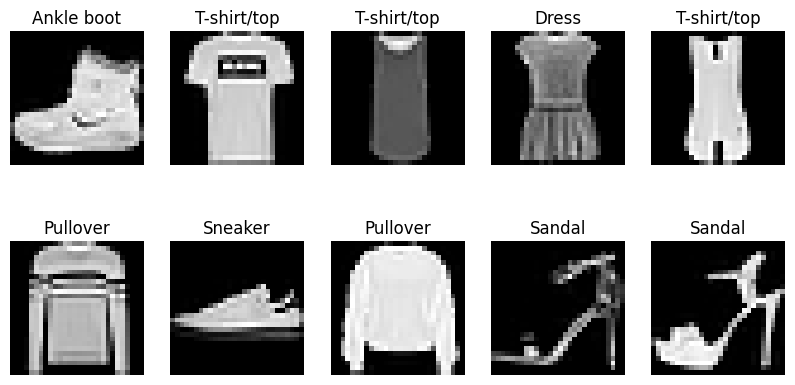

In [19]:
# plot the first 10 images
fig, ax = plt.subplots(2, 5, figsize=(10, 5))
for i in range(10):
    ax[i//5, i%5].imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax[i//5, i%5].axis('off')
    ax[i//5, i%5].set_title(classes[y_train[i]])

## 2. Train a Support Vector Machine for Image Classification

**TODO**: Import a linear support vector classifier (SVC) from scikit-learn and fit it on the training data!

In [20]:
# TODO: YOUR CODE GOES HERE
from sklearn.svm import LinearSVC

# scale pixel values to help liblinear converge faster
X_train_svc = X_train.astype("float32") / 255.0
X_test_svc = X_test.astype("float32") / 255.0

# create a linear SVC model with more iterations for convergence
model = LinearSVC(max_iter=5000, dual="auto", tol=1e-3, random_state=42)

# fit the model to the training data
model.fit(X_train_svc, y_train)

# predict the labels of the test data
y_pred = model.predict(X_test_svc)

**TODO:** Evaluate the model on the test data and print the accuracy.

In [21]:
# TODO: YOUR CODE GOES HERE


from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")


Test Accuracy: 0.7965


**TODO**: Plot some sample images including their labels and predictions for comparison!

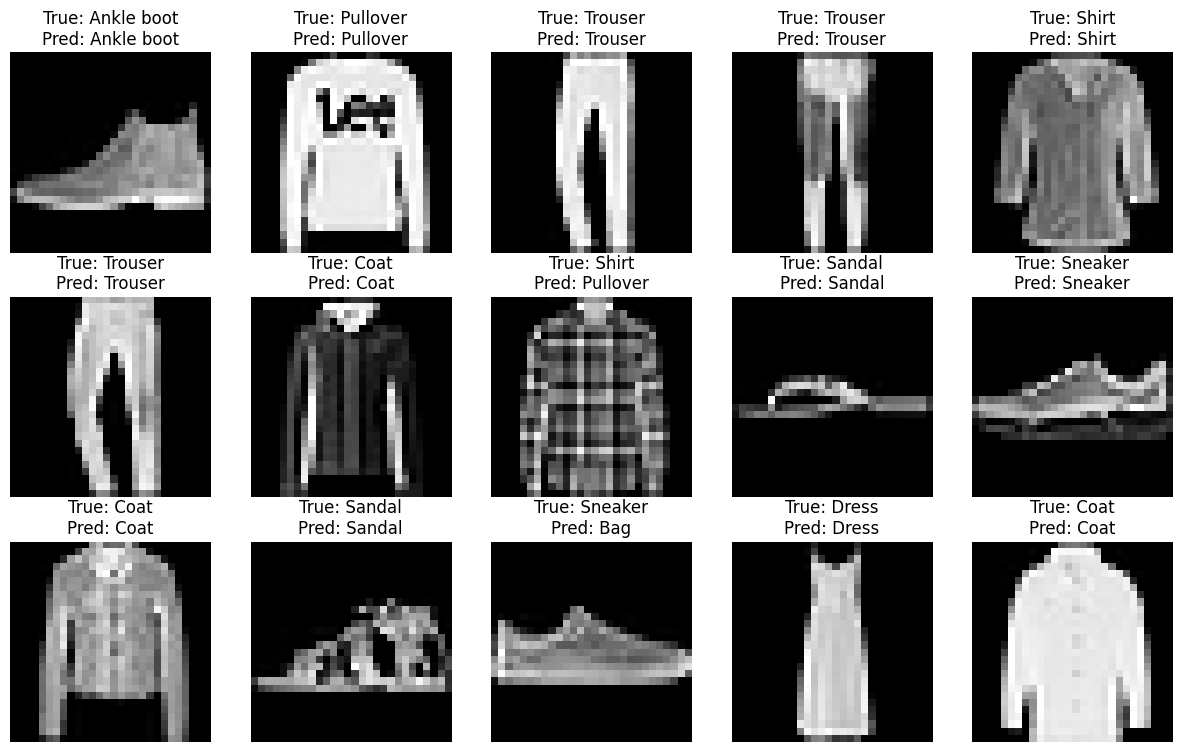

In [22]:
# TODO: YOUR CODE GOES HERE

fig, ax = plt.subplots(3, 5, figsize=(15, 9))
for i in range(15):
    ax[i//5, i%5].imshow(X_test[i].reshape(28, 28), cmap='gray')
    ax[i//5, i%5].axis('off')
    ax[i//5, i%5].set_title(f"True: {classes[y_test[i]]}\nPred: {classes[y_pred[i]]}")
plt.show()

**TODO**: Plot the confusion matrix for your predictions!

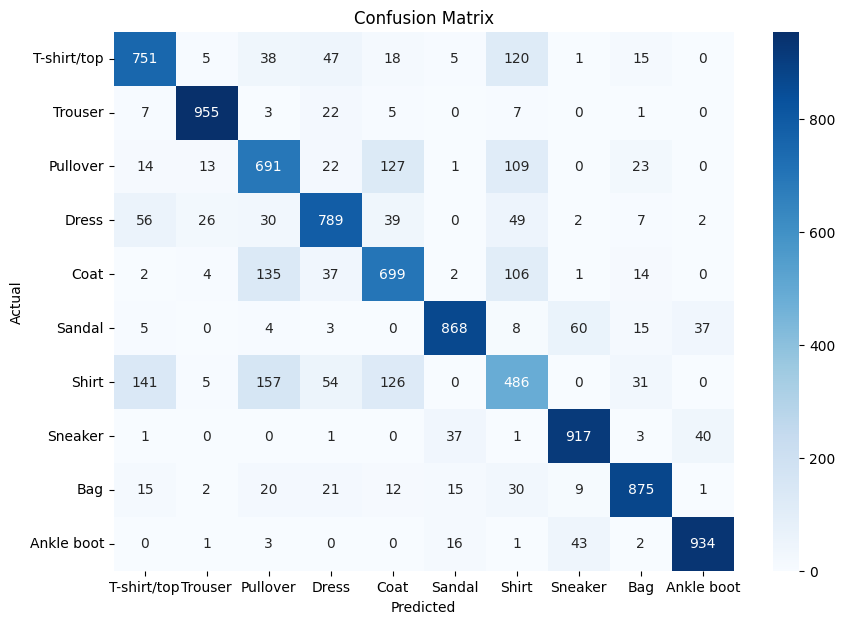

In [23]:
# TODO: YOUR CODE GOES HERE

from sklearn.metrics import confusion_matrix
import seaborn as sns 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 3. Model Fine-Tuning

**TODO**: Optimize your model using grid search and cross validation!

In [24]:
# TODO: YOUR CODE GOES HERE
# optimize the model using GridSearch and cross-validation
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'max_iter': [1000, 5000, 10000]
}

cv_folds = 3
grid_search = GridSearchCV(
    LinearSVC(dual="auto", tol=1e-3, random_state=42),
    param_grid,
    cv=cv_folds,
    n_jobs=-1,
)
grid_search.fit(X_train_svc, y_train)

GridSearchCV(cv=3, estimator=LinearSVC(random_state=42, tol=0.001), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'max_iter': [1000, 5000, 10000]})

**TODO**: Evaluate your best model: Print the optimal parameters and calculate the accuracy!

In [25]:
# TODO: YOUR CODE GOES HERE

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best mean cross-validation accuracy ({cv_folds}-fold): {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_svc)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Test Accuracy after GridSearch: {accuracy_best:.4f}")

Best parameters: {'C': 0.01, 'max_iter': 1000}
Best mean cross-validation accuracy (3-fold): 0.8332
Test Accuracy after GridSearch: 0.8293
